# Long Gutenberg — context coverage

How far past the training `seq_len` the extended Gutenberg excerpts reach, per
repetition bucket. Uses the lightweight `lengths.jsonl` (one row per book, per
bucket — no tokens) built by
`attn_bench/data_processing/books/extract_long_context.py`.

Each row: `book_id`, `bucket_rep`, `extra_prefix_len` (warmup before the sample),
`extra_suffix_len` (continuation after it). The measured 8,190-token probe sits in
the middle. The coverage curve below bounds how far past `seq_len` the position-wise
loss experiment can stay well-supported before too few sequences remain.


In [10]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# One row per book, per repetition bucket. Transfer this file locally from the cluster.
LENGTHS_PATH = Path("../results/data/gutenberg-long/lengths.jsonl")

SEQ_LEN = 8192      # training sequence length (referred to as 1L below)
SAMPLE_LEN = 8190   # canonical content tokens per probe
HUE = "#4292C6"     # single sequential hue -- the overall curve

rows = [json.loads(l) for l in LENGTHS_PATH.open()]
df = pd.DataFrame(rows)
BUCKETS = sorted(int(b) for b in df["bucket_rep"].unique())
print(f"{len(df):,} rows, {len(BUCKETS)} buckets: {BUCKETS}")

6,600 rows, 10 buckets: [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]


## Coverage — how far the context reaches

For each position (measured from the sample start), what fraction of sequences still
have a real token there. The sample band `[0, 8190)` is always full; the prefix
extends left (negative) and the suffix right. Dotted lines mark multiples of
`seq_len`.


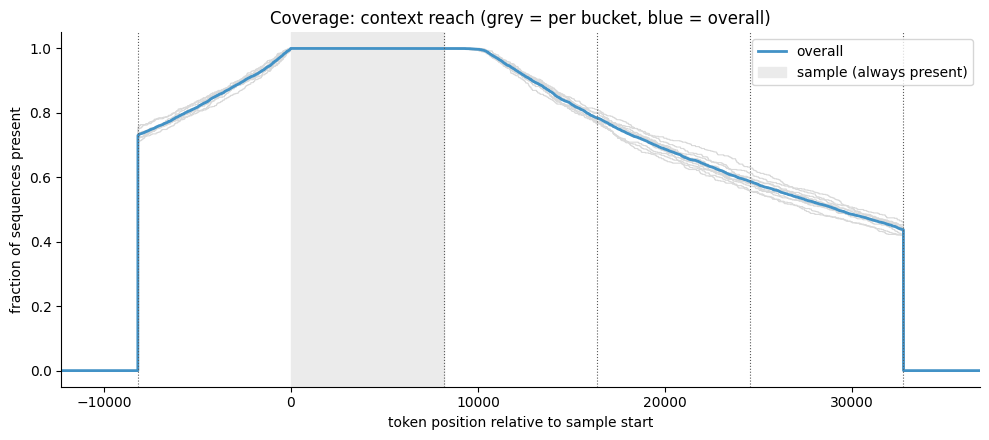

In [14]:
L = SEQ_LEN
xs_pre = np.arange(int(-1.5 * L), 0)   # 1.5L of warmup before the sample start
xs_suf = np.arange(0, int(4.5 * L))    # 3.5L past the sample start

def coverage_frac(sub):
    n = len(sub)
    p = np.sort(sub["extra_prefix_len"].to_numpy())
    s = np.sort(sub["extra_suffix_len"].to_numpy())
    pre = (n - np.searchsorted(p, -xs_pre, "left")) / n
    d_suf = np.maximum(xs_suf - SAMPLE_LEN, 0)          # tokens needed past the sample
    suf = (n - np.searchsorted(s, d_suf, "left")) / n
    suf[d_suf == 0] = 1.0                               # inside the sample: always present
    return np.concatenate([xs_pre, xs_suf]), np.concatenate([pre, suf])

fig, ax = plt.subplots(figsize=(10, 4.5))
for rep in BUCKETS:
    x, y = coverage_frac(df[df["bucket_rep"] == rep])
    ax.plot(x, y, color="0.85", linewidth=0.8)        # per-bucket, recessive
x, y = coverage_frac(df)
ax.plot(x, y, color=HUE, linewidth=2, label="overall")
ax.axvspan(0, SAMPLE_LEN, color="0.92", label="sample (always present)")
for pos in (-L, L, 2 * L, 3 * L, 4 * L):
    ax.axvline(pos, color="0.35", linestyle=":", linewidth=0.8)
ax.set_xlim(xs_pre[0], xs_suf[-1])
ax.set_xlabel("token position relative to sample start")
ax.set_ylabel("fraction of sequences present")
ax.set_title("Coverage: context reach (grey = per bucket, blue = overall)")
ax.legend(loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()